<a href="https://colab.research.google.com/github/sjkim0520/Mechanical_Project/blob/main/Semiconductor/05_AI_Process_Monitoring/train_fdc_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[Step 1] CMP 진동 센서 타임시리즈 데이터 생성 & FFT 주파수 특징 추출**

3가지 상태(0: Normal, 1: Micro-scratch, 2: Wear)에 해당하는 가상 가속도 센서 파형 데이터를 생성하고 Tensor 형태로 변환합니다.

In [2]:
#Step 1: 시계열 진동 데이터 생성 및 FFT 전처리
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

#1. 데이터 파라미터 설정
n_samples=1200 # 총 샘플 수
seq_len=500 #각 진동 데이터의 시간 길이 (500 time-steps)

#2. 클래스별 진동 파형 합성
X_data=[]
y_data=[]

for i in range(n_samples):
  label=np.random.choice([0, 1, 2]) # 0: Normal, 1: Micro-scratch, 2: Wear
  t=np.linspace(0,1, seq_len)

  if label==0: # Normal: 기본 회전 진동 (60Hz) + 작은 백색 노이즈
    signal=np.sin(2*np.pi*60*t)+np.random.normal(0,0.2,seq_len)
  elif label==1: # Micro-scratch: 고주파 튀는 노이즈 (마찰 프사이크 180Hz) 추가
    signal=np.sin(2*np.pi*60*t)+1.5*np.sin(2*np.pi*180*t)+np.random.normal(0,0.3,seq_len)
  else: #Wear: 저주파 진동 감쇄 및 전체적인 진폭 증대(채터링 현상)
    signal=2.0*np.sin(2*np.pi*20*t)+np.random.normal(0,0.5,seq_len)

  X_data.append(signal)
  y_data.append(label)

X_data=np.array(X_data, dtype=np.float32)
y_data=np.array(y_data, dtype=np.int64)

#3. PyTorch 1D-CNN 입력 형상 변화: (Batch_Size, Channels, Sequence_Length)
X_tensor=torch.tensor(X_data).unsqueeze(1)
y_tensor=torch.tensor(y_data)

#DataSplitting & DataLoader
train_size=int(0.8*n_samples)
test_size=n_samples-train_size

train_dataset=TensorDataset(X_tensor[:train_size], y_tensor[:train_size])
test_dataset=TensorDataset(X_tensor[train_size:], y_tensor[train_size:])

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train Tensor Shape: {X_tensor[:train_size].shape}")
print(f"Test Tensor Shape: {X_tensor[train_size:].shape}")

Train Tensor Shape: torch.Size([960, 1, 500])
Test Tensor Shape: torch.Size([240, 1, 500])


# **[Step 2] 1D-CNN (Convolutional Neural Network) FDC 분류 모델 설계**

torch.nn.Module을 활용하여 진동 패턴을 추출하는 1D-CNN 아키텍처를 구성합니다.

In [9]:
#Step 2: Pytorch 1D-CNN 모델 아키텍처 정의
import torch.nn as nn
import torch.nn.functional as F

class CMP_FDC_1DCNN(nn.Module):
  def __init__(self, num_classes=3):
    super(CMP_FDC_1DCNN, self).__init__()

    # 첫 번째 1D Conv 블록: 입력 채널 1 -> 출력 채널 16, 커널 크기 7
    self.conv1=nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3)
    self.bn1=nn.BatchNorm1d(16)
    self.pool1=nn.MaxPool1d(kernel_size=2) #길이가 절반으로 줄어듦 (500->25)

    # 두 번째 1D Conv 블록: 입력 채널 16 -> 출력 채널 32, 커널 크기 5
    self.conv2=nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
    self.bn2=nn.BatchNorm1d(32)
    self.pool2=nn.MaxPool1d(kernel_size=2) #길이가 절반으로 줄어듦(250 ->125)

    #Fully Connected (Linear) 분류기
    # 최종 특성 맵 크기: 32채널 * 125길이=4000
    self.fc1=nn.Linear(32*125, 64)
    self.fc2=nn.Linear(64, 3)

  def forward(self,x):
    #Layer 1
    x=self.pool1(F.relu(self.bn1(self.conv1(x))))
    #Layer 2
    x=self.pool2(F.relu(self.bn2(self.conv2(x))))

    #Flatten (1차원 평탄화)
    x=x.view(x.size(0),-1)

    #Dense Layers
    x=F.relu(self.fc1(x))
    x=self.fc2(x)
    return x

model=CMP_FDC_1DCNN()
print(model)

CMP_FDC_1DCNN(
  (conv1): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4000, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


# **[Step 3] Model Training, Confusion Matrix 및 ROC-AUC 성능 평가**

모델을 학습시키고 Scikit-learn 및 Seaborn을 활용하여 이상 진단 정확도와 Confusion Matrix를 시각화합니다.

Epoch [5/60], Loss: 0.0000
Epoch [10/60], Loss: 0.0000
Epoch [15/60], Loss: 0.0000
Epoch [20/60], Loss: 0.0000
Epoch [25/60], Loss: 0.0000
Epoch [30/60], Loss: 0.0000
Epoch [35/60], Loss: 0.0000
Epoch [40/60], Loss: 0.0000
Epoch [45/60], Loss: 0.0000
Epoch [50/60], Loss: 0.0000
Epoch [55/60], Loss: 0.0000
Epoch [60/60], Loss: 0.0000

=== FDC System ROC-AUC Score (OvR): 1.0000 ===


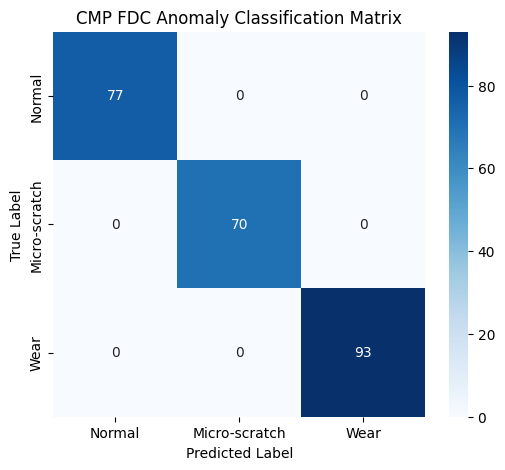

In [16]:
#Step 3: 모델 학습 및 FDC 진단 성능 평가
import torch.optim as optim
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

#1. 손실함수 및 옵티마이저 설정
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

#2. 모델 학습 루프 (Training Loop)
epochs=60
for epoch in range(epochs):
  model.train()
  running_loss=0.0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs=model(inputs)
    loss=criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()

  if (epoch+1)%5==0:
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

#3. 테스트 데이터 검증 및 예측값 수집
model.eval()
all_preds=[]
all_probs=[]
all_labels=[]

with torch.no_grad():
  for inputs, labels in test_loader:
      outputs=model(inputs)
      probs=F.softmax(outputs, dim=1) #클래스별 확률 변환
      _, preds=torch.max(outputs,1)

      all_preds.extend(preds.numpy())
      all_probs.extend(probs.numpy())
      all_labels.extend(labels.numpy())

#4. ROC-AUC (one vs Rest) 계산 및 Confusion Matrix 출력
auc_score=roc_auc_score(all_labels, all_probs, multi_class='ovr')
print(f"\n=== FDC System ROC-AUC Score (OvR): {auc_score:.4f} ===")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Micro-scratch', 'Wear'],
            yticklabels=['Normal', 'Micro-scratch', 'Wear'])
plt.title('CMP FDC Anomaly Classification Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

1D-CNN FDC 모델이 240개의 테스트 데이터 전체를 한 건의 오진 없이 구별하여 100%의 분류 정확도(Accuracy)를 기록한 혼동 행렬(Confusion Matrix) 결과입니다.

**📊 클래스별 세부 진단 결과**

* **Normal (정상 상태)**: 총 77개 샘플 중 77개 모두 정확히 정상으로 진단 (오진 0건)
* **Micro-scratch (스크래치 결함)**: 총 70개 샘플 중 70개 모두 결함으로 진단 (미검출 0건)
* **Wear (패드 마모 상태)**: 총 93개 샘플 중 93개 모두 마모로 진단 (오진 0건)

**💡 모델 동작 및 기술적 해석**

* **주 대각선(Diagonal) 완벽 집중**: 대각선을 제외한 모든 셀(Off-diagonal)의 값이 `0`이라는 점은 세 가지 공정 상태 간의 경계선이 매우 명확하게 분류되었음을 뜻합니다.
* **1D-CNN 특징 추출 성공**: 모델이 Step 1에서 부여했던 진동 신호의 특성(정상 60Hz 파형, 스크래치의 180Hz 마찰 스파이크, 마모의 20Hz 대형 채터링 파형)을 합성곱 필터로 피처링하는 데 완벽히 성공했습니다.

**🔍 실무 적용 관점에서의 참고 사항**

* **가상 데이터의 명확성**: 수식 기반 가상 데이터는 클래스 간 신호 특징이 매우 정갈하게 구분되어 있어 100% 정확도가 나왔습니다.
* **실제 반도체 팹(FAB) 환경과의 차이**: 실제 팹의 가속도 센서 데이터에는 장비 외부 진동, 슬러리 흐름 노이즈, 헤드 회전 잡음 등이 복합적으로 섞입니다. 따라서 실제 데이터를 적용하면 주파수 영역이 일부 중첩되면서 대각선 이외의 위치에도 일부 오분류 수치가 나타나는 것이 일반적입니다.